# Ingesta y preprocesamiento

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [ ]:
df = pd.read_csv("mobile_phone_price.csv")

In [ ]:
df

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799
...,...,...,...,...,...,...,...,...
402,Samsung,Galaxy Note20 5G,128,8,6.7,12+64+12,4300,1049
403,Xiaomi,Mi 10 Lite 5G,128,6,6.57,48+8+2+2,4160,349
404,Apple,iPhone 12 Pro Max,128,6,6.7,12+12+12,3687,1099
405,Oppo,Reno3,128,8,6.4,48+13+8+2,4025,429


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Brand                   407 non-null    object
 1   Model                   407 non-null    object
 2   Storage                 407 non-null    object
 3   RAM                     407 non-null    object
 4   Screen Size (inches)    407 non-null    object
 5   Camera (MP)             407 non-null    object
 6   Battery Capacity (mAh)  407 non-null    int64 
 7   Price ($)               407 non-null    object
dtypes: int64(1), object(7)
memory usage: 25.6+ KB


In [ ]:
df["Brand"].value_counts(normalize=True)*100

Brand
Samsung       19.410319
Xiaomi        16.461916
Oppo          13.759214
Realme        10.565111
Vivo           8.599509
Apple          7.371007
Nokia          6.879607
Motorola       5.651106
OnePlus        3.685504
Huawei         2.948403
Google         1.719902
Asus           0.982801
LG             0.737101
Blackberry     0.737101
Sony           0.245700
CAT            0.245700
Name: proportion, dtype: float64

<Axes: xlabel='Brand'>

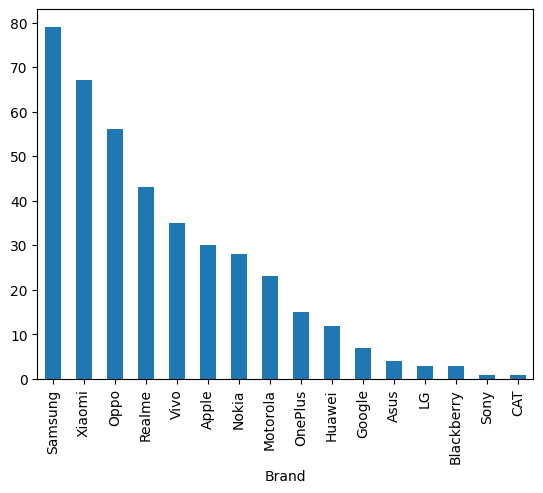

In [ ]:
df["Brand"].value_counts().plot(kind="bar")

In [ ]:
brand_counts = df["Brand"].value_counts()
brand_otros = list(brand_counts[brand_counts < 10].index)
brand_otros

['Google', 'Asus', 'LG', 'Blackberry', 'Sony', 'CAT']

In [ ]:
df["Brand"] = df["Brand"].apply(lambda x: "Otros" if x in brand_otros else x)

<Axes: xlabel='Brand'>

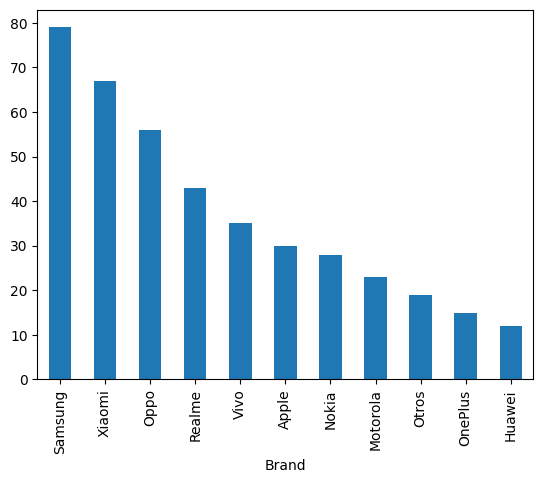

In [ ]:
df["Brand"].value_counts().plot(kind="bar")

In [ ]:
df["Model"].value_counts()

Model
Poco X3 Pro           6
Y33s                  5
iPhone XR             5
C21Y                  5
Redmi 10 Prime        5
                     ..
Mi 11 Lite NE         1
Moto G Stylus 2021    1
A54s 5G               1
Galaxy M52            1
Reno3                 1
Name: count, Length: 239, dtype: int64

In [ ]:
df

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Otros,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799
...,...,...,...,...,...,...,...,...
402,Samsung,Galaxy Note20 5G,128,8,6.7,12+64+12,4300,1049
403,Xiaomi,Mi 10 Lite 5G,128,6,6.57,48+8+2+2,4160,349
404,Apple,iPhone 12 Pro Max,128,6,6.7,12+12+12,3687,1099
405,Oppo,Reno3,128,8,6.4,48+13+8+2,4025,429


In [ ]:
column_names = {
    "Storage ": "Storage",
    "RAM ": "RAM",
    "Screen Size (inches)": "Screen size",
    "Battery Capacity (mAh)": "Battery capacity",
    "Price ($)": "Price"
}

In [ ]:
df = df.rename(columns=column_names)

In [ ]:
df.columns

Index(['Brand', 'Model', 'Storage', 'RAM', 'Screen size', 'Camera (MP)',
       'Battery capacity', 'Price'],
      dtype='object')

In [ ]:
df["Storage"].value_counts()

Storage
128GB     125
128        74
128 GB     51
64GB       49
32GB       27
256        23
64         18
64 GB      16
256GB      10
256 GB      7
32 GB       3
512         3
32          1
Name: count, dtype: int64

In [ ]:
df["Storage"] = df["Storage"].apply(lambda x: x.replace("GB", "").replace(" ", "")).astype("int64")

<Axes: >

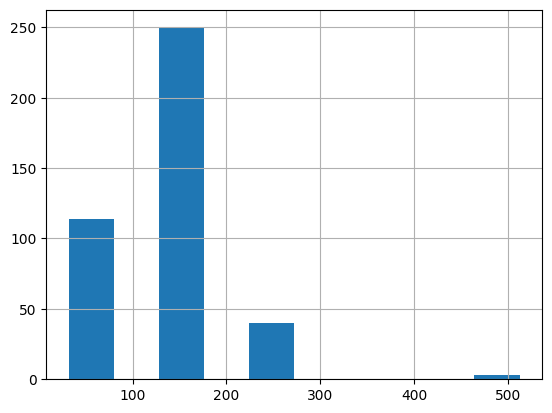

In [ ]:
df["Storage"].hist()

<Axes: >

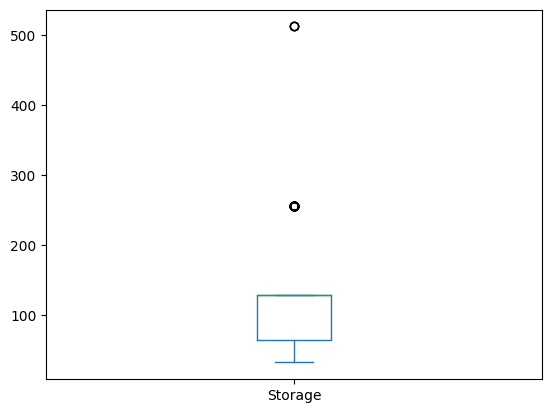

In [ ]:
df["Storage"].plot(kind="box")

In [ ]:
df["RAM"].value_counts()

RAM
4GB      68
6GB      59
8GB      42
4        35
8        34
6        28
4 GB     25
3GB      22
6 GB     20
8 GB     19
12       11
12GB      9
2GB       9
3         9
3 GB      7
12 GB     5
5GB       2
2 GB      1
16        1
2         1
Name: count, dtype: int64

In [ ]:
df["RAM"] = df["RAM"].apply(lambda x: x.replace("GB", "").replace(" ", "")).astype("int64")

<Axes: >

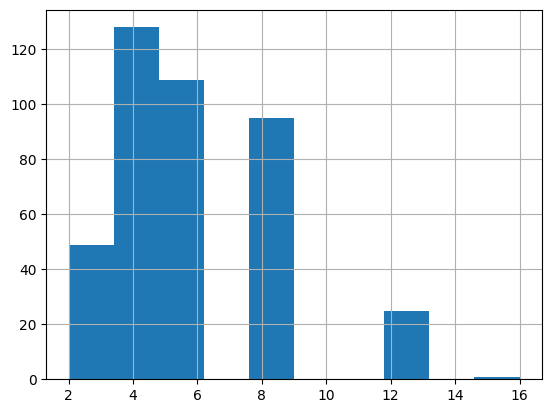

In [ ]:
df["RAM"].hist()

In [ ]:
df["Screen size"].value_counts()

Screen size
6.5               108
6.67               30
6.4                26
6.7                25
6.55               21
6.43               21
6.51               19
6.1                16
6.53               16
6.58               14
6.6                14
6.52               14
6.8                 9
6.44                8
6.39                7
4.7                 5
6.81                5
6                   4
6.3                 4
6.82                4
6.2                 4
6.78                4
5.4                 3
6.62                3
6.9                 3
4.5                 2
5.5                 2
6.49                2
6.72                2
7.6 (unfolded)      1
6.15                1
6.47                1
5.7                 1
6.8 + 3.9           1
6.76                1
6.35                1
6.22                1
5.99                1
5.9                 1
6.56                1
6.57                1
Name: count, dtype: int64

In [ ]:
df["Screen size"] = df["Screen size"].apply(lambda x: x.split(" ")[0]).astype("float64")

<Axes: ylabel='Frequency'>

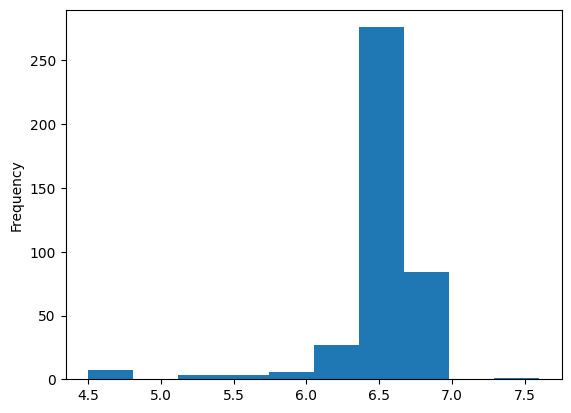

In [ ]:
df["Screen size"].plot(kind="hist")

In [ ]:
df["Price"] = df["Price"].apply(lambda x: re.sub('[^0-9]','', x)).astype("int64")

<Axes: >

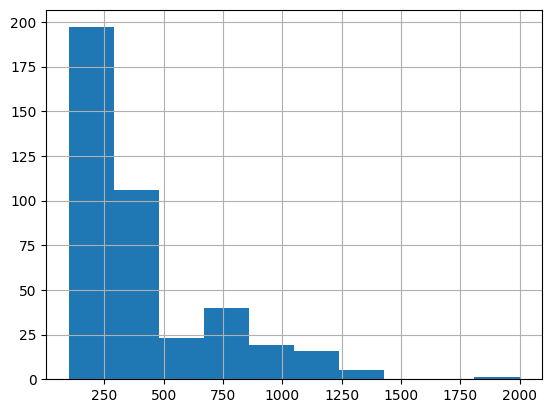

In [ ]:
df.Price.hist()

In [ ]:
df[df["Camera (MP)"].str.contains("MP")]["Camera (MP)"]

77                12MP + 12MP
78         64MP + 12MP + 12MP
79           50MP + 8MP + 2MP
80                50MP + 12MP
81     48MP + 8MP + 2MP + 2MP
                ...          
283          12MP + 2MP + 2MP
284          13MP + 8MP + 2MP
285          12MP + 2MP + 2MP
286    48MP + 8MP + 2MP + 2MP
287          25MP + 8MP + 5MP
Name: Camera (MP), Length: 211, dtype: object

In [ ]:
def preprocess_camera_feature(x):
  return df["Camera (MP)"].apply(
    lambda x: [
        float(i) for i in
        x.replace(" ", "")
        .replace("MP", "")
        .split("+")
        if i not in ["3D", "ToF"]
      ]
  )

In [ ]:
df["Camera (MP)"] = preprocess_camera_feature(df["Camera (MP)"])
df["Camera (MP)"]

0             [12.0, 12.0, 12.0]
1      [108.0, 10.0, 10.0, 12.0]
2         [48.0, 50.0, 8.0, 2.0]
3          [64.0, 8.0, 5.0, 2.0]
4                   [50.0, 12.2]
                 ...            
402           [12.0, 64.0, 12.0]
403        [48.0, 8.0, 2.0, 2.0]
404           [12.0, 12.0, 12.0]
405       [48.0, 13.0, 8.0, 2.0]
406            [48.0, 12.0, 5.0]
Name: Camera (MP), Length: 407, dtype: object

In [ ]:
df["Number of cameras"] = df["Camera (MP)"].apply(lambda x: len(x))
df["Average camera resolution"] = df["Camera (MP)"].apply(lambda x: np.mean(x))
df["Max camera resolution"] = df["Camera (MP)"].apply(lambda x: np.max(x))
df

,Brand,Model,Storage,RAM,Screen size,Camera (MP),Battery capacity,Price,Number of cameras,Average camera resolution,Max camera resolution
0,Apple,iPhone 13 Pro,128,6,6.10,"[12.0, 12.0, 12.0]",3095,999,3,12.000000,12.0
1,Samsung,Galaxy S21 Ultra,256,12,6.80,"[108.0, 10.0, 10.0, 12.0]",5000,1199,4,35.000000,108.0
2,OnePlus,9 Pro,128,8,6.70,"[48.0, 50.0, 8.0, 2.0]",4500,899,4,27.000000,50.0
3,Xiaomi,Redmi Note 10 Pro,128,6,6.67,"[64.0, 8.0, 5.0, 2.0]",5020,279,4,19.750000,64.0
4,Otros,Pixel 6,128,8,6.40,"[50.0, 12.2]",4614,799,2,31.100000,50.0
...,...,...,...,...,...,...,...,...,...,...,...
402,Samsung,Galaxy Note20 5G,128,8,6.70,"[12.0, 64.0, 12.0]",4300,1049,3,29.333333,64.0
403,Xiaomi,Mi 10 Lite 5G,128,6,6.57,"[48.0, 8.0, 2.0, 2.0]",4160,349,4,15.000000,48.0
404,Apple,iPhone 12 Pro Max,128,6,6.70,"[12.0, 12.0, 12.0]",3687,1099,3,12.000000,12.0
405,Oppo,Reno3,128,8,6.40,"[48.0, 13.0, 8.0, 2.0]",4025,429,4,17.750000,48.0


In [ ]:
df = df[[
  "Brand",
  "Storage",
  "RAM",
  "Screen size",
  "Battery capacity",
  "Number of cameras",
  "Average camera resolution",
  "Max camera resolution",
  "Price"
]]
df

,Brand,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution,Price
0,Apple,128,6,6.10,3095,3,12.000000,12.0,999
1,Samsung,256,12,6.80,5000,4,35.000000,108.0,1199
2,OnePlus,128,8,6.70,4500,4,27.000000,50.0,899
3,Xiaomi,128,6,6.67,5020,4,19.750000,64.0,279
4,Otros,128,8,6.40,4614,2,31.100000,50.0,799
...,...,...,...,...,...,...,...,...,...
402,Samsung,128,8,6.70,4300,3,29.333333,64.0,1049
403,Xiaomi,128,6,6.57,4160,4,15.000000,48.0,349
404,Apple,128,6,6.70,3687,3,12.000000,12.0,1099
405,Oppo,128,8,6.40,4025,4,17.750000,48.0,429


In [ ]:
df.describe()

,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution,Price
count,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000
mean,123.046683,5.837838,6.471253,4676.476658,3.127764,18.012510,43.786241,408.314496
std,64.963160,2.431980,0.320542,797.193713,0.777384,8.893131,24.530789,299.684768
min,32.000000,2.000000,4.500000,1821.000000,1.000000,5.000000,8.000000,99.000000
25%,64.000000,4.000000,6.440000,4300.000000,3.000000,12.000000,13.000000,199.000000
50%,128.000000,6.000000,6.500000,5000.000000,3.000000,17.333333,48.000000,299.000000
75%,128.000000,8.000000,6.590000,5000.000000,4.000000,22.250000,64.000000,499.000000
max,512.000000,16.000000,7.600000,7000.000000,4.000000,56.000000,108.000000,1999.000000


<Axes: xlabel='Storage', ylabel='Price'>

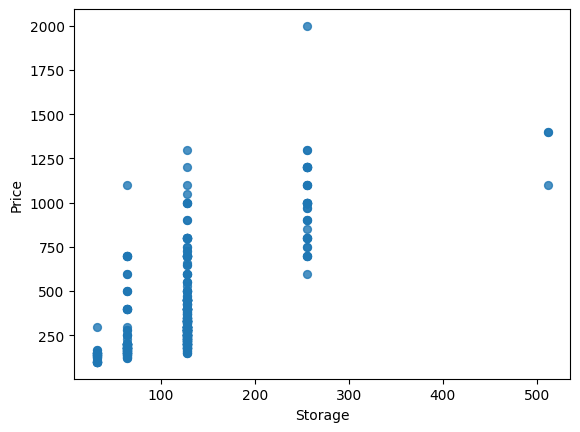

In [ ]:
df.plot(kind='scatter', x='Storage', y='Price', s=32, alpha=.8)

<Axes: xlabel='Screen size', ylabel='Price'>

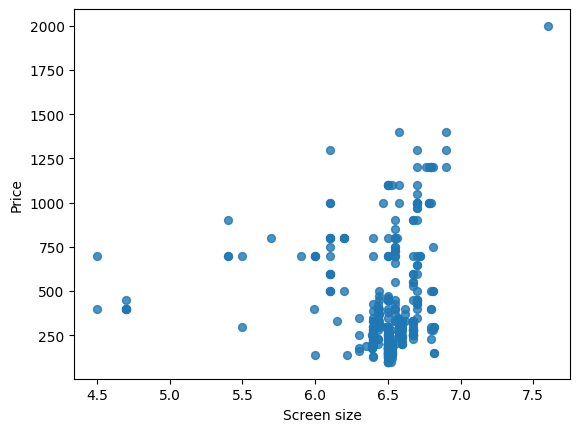

In [ ]:
df.plot(kind='scatter', x='Screen size', y='Price', s=32, alpha=.8)

<Axes: xlabel='Number of cameras', ylabel='Price'>

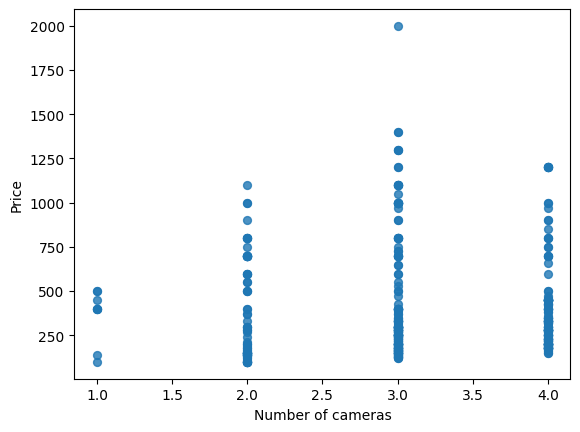

In [ ]:
df.plot(kind='scatter', x='Number of cameras', y='Price', s=32, alpha=.8)

<Axes: xlabel='Number of cameras', ylabel='Price'>

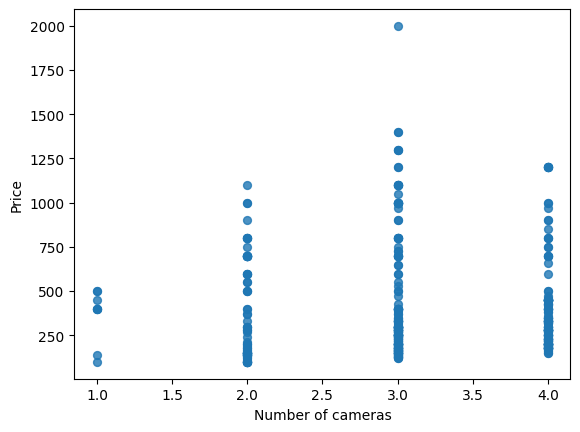

In [ ]:
df.plot(kind='scatter', x='Number of cameras', y='Price', s=32, alpha=.8)

In [ ]:
df[["Brand", "Price"]].groupby("Brand").mean().sort_values("Price")

,Price
Brand,
Realme,206.906977
Nokia,244.714286
Motorola,278.130435
Xiaomi,282.880597
Vivo,323.000000
Oppo,376.142857
Samsung,480.405063
OnePlus,644.333333
Otros,701.631579


<Axes: xlabel='Brand', ylabel='Price'>

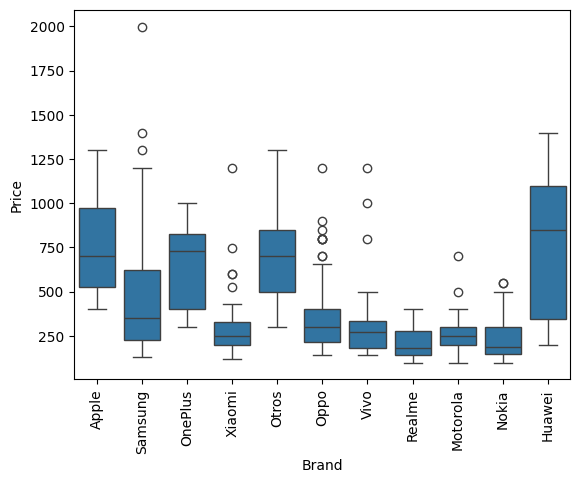

In [ ]:
plt.xticks(rotation=90)
sns.boxplot(data=df, x="Brand", y="Price")

In [ ]:
df.select_dtypes("number").corr()

,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution,Price
Storage,1.000000,0.691341,0.258174,-0.074952,0.240425,0.527809,0.386796,0.711050
RAM,0.691341,1.000000,0.294291,-0.027627,0.311933,0.624316,0.531552,0.637172
Screen size,0.258174,0.294291,1.000000,0.609917,0.444354,0.272738,0.392683,0.046344
Battery capacity,-0.074952,-0.027627,0.609917,1.000000,0.400738,0.061726,0.285201,-0.396581
Number of cameras,0.240425,0.311933,0.444354,0.400738,1.000000,0.106018,0.470931,0.000165
Average camera resolution,0.527809,0.624316,0.272738,0.061726,0.106018,1.000000,0.838692,0.435755
Max camera resolution,0.386796,0.531552,0.392683,0.285201,0.470931,0.838692,1.000000,0.156042
Price,0.711050,0.637172,0.046344,-0.396581,0.000165,0.435755,0.156042,1.000000


# Encoding & Scaling

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
categorical_features = X.select_dtypes("object").columns
numerical_features = X.select_dtypes("number").columns

In [ ]:
encoder = OneHotEncoder()
encoded_df = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_df.toarray(), columns=encoder.get_feature_names_out())
encoded_df

,Brand_Apple,Brand_Huawei,Brand_Motorola,Brand_Nokia,Brand_OnePlus,Brand_Oppo,Brand_Otros,Brand_Realme,Brand_Samsung,Brand_Vivo,Brand_Xiaomi
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
404,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
405,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X[categorical_features]

,Brand
0,Apple
1,Samsung
2,OnePlus
3,Xiaomi
4,Otros
...,...
402,Samsung
403,Xiaomi
404,Apple
405,Oppo


In [ ]:
X[numerical_features].describe()

,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution
count,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000
mean,123.046683,5.837838,6.471253,4676.476658,3.127764,18.012510,43.786241
std,64.963160,2.431980,0.320542,797.193713,0.777384,8.893131,24.530789
min,32.000000,2.000000,4.500000,1821.000000,1.000000,5.000000,8.000000
25%,64.000000,4.000000,6.440000,4300.000000,3.000000,12.000000,13.000000
50%,128.000000,6.000000,6.500000,5000.000000,3.000000,17.333333,48.000000
75%,128.000000,8.000000,6.590000,5000.000000,4.000000,22.250000,64.000000
max,512.000000,16.000000,7.600000,7000.000000,4.000000,56.000000,108.000000


In [ ]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df[numerical_features])
scaled_df = pd.DataFrame(scaled_df, columns=scaler.feature_names_in_)
scaled_df

,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution
0,0.076342,0.066761,-1.159628,-1.986246,-0.164554,-0.676917,-1.297364
1,2.049114,2.536923,1.026858,0.406327,1.123395,1.912532,2.620902
2,0.076342,0.890149,0.714503,-0.221645,1.123395,1.011854,0.253616
3,0.076342,0.066761,0.620796,0.431446,1.123395,0.195615,0.825030
4,0.076342,0.890149,-0.222563,-0.078467,-1.452503,1.473451,0.253616
...,...,...,...,...,...,...,...
402,0.076342,0.890149,0.714503,-0.472834,-0.164554,1.274552,0.825030
403,0.076342,0.066761,0.308441,-0.648666,1.123395,-0.339163,0.171986
404,0.076342,0.066761,0.714503,-1.242727,-0.164554,-0.676917,-1.297364
405,0.076342,0.890149,-0.222563,-0.818218,1.123395,-0.029555,0.171986


In [ ]:
X = pd.concat([encoded_df, scaled_df], axis=1)
X

,Brand_Apple,Brand_Huawei,Brand_Motorola,Brand_Nokia,Brand_OnePlus,Brand_Oppo,Brand_Otros,Brand_Realme,Brand_Samsung,Brand_Vivo,Brand_Xiaomi,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.076342,0.066761,-1.159628,-1.986246,-0.164554,-0.676917,-1.297364
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.049114,2.536923,1.026858,0.406327,1.123395,1.912532,2.620902
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.076342,0.890149,0.714503,-0.221645,1.123395,1.011854,0.253616
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.076342,0.066761,0.620796,0.431446,1.123395,0.195615,0.825030
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.076342,0.890149,-0.222563,-0.078467,-1.452503,1.473451,0.253616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.076342,0.890149,0.714503,-0.472834,-0.164554,1.274552,0.825030
403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.076342,0.066761,0.308441,-0.648666,1.123395,-0.339163,0.171986
404,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.076342,0.066761,0.714503,-1.242727,-0.164554,-0.676917,-1.297364
405,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.076342,0.890149,-0.222563,-0.818218,1.123395,-0.029555,0.171986


# Entrenamiento

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
models = [LinearRegression(), KNeighborsRegressor(), DecisionTreeRegressor(), MLPRegressor()]

for model in models:
  model.fit(X_train, y_train)
  y_pred = pd.Series(model.predict(X_test))
  y_pred.index = y_test.index
  print(str(model))
  print("MAE: ", mean_absolute_error(y_test, y_pred))
  print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
  print("R2: ", r2_score(y_test, y_pred))

LinearRegression()
MAE:  89.70808679499106
RMSE:  123.7590016064929
R2:  0.8248211760667632
KNeighborsRegressor()
MAE:  68.92926829268292
RMSE:  111.7994306019795
R2:  0.857042417479723
DecisionTreeRegressor()
MAE:  66.60264227642276
RMSE:  128.0967413810321
R2:  0.8123259716575191
MLPRegressor()
MAE:  363.8976172425816
RMSE:  446.93492040515696
R2:  -1.2846337574514428


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
y_pred = pd.Series(models[1].predict(X_test))
y_pred.index = y_test.index

In [ ]:
results = pd.concat([df.loc[y_test.index], pd.DataFrame(y_pred)], axis=1)
results.columns = list(df.columns)[:-1] + ["Real Price", "Predicted Price"]
results

,Brand,Storage,RAM,Screen size,Battery capacity,Number of cameras,Average camera resolution,Max camera resolution,Real Price,Predicted Price
294,Oppo,128,8,6.55,4350,4,19.000000,64.0,449,427.0
85,Motorola,256,12,6.70,4500,3,44.000000,108.0,699,1009.0
113,Otros,128,6,6.80,4300,3,20.333333,48.0,499,515.0
121,Samsung,128,6,6.40,6000,4,19.000000,64.0,279,301.0
99,Otros,128,6,5.90,4000,2,38.000000,64.0,699,533.0
...,...,...,...,...,...,...,...,...,...,...
195,Oppo,128,6,6.50,5000,3,17.333333,48.0,299,283.0
145,Xiaomi,128,4,6.50,6000,4,15.500000,50.0,189,197.0
47,Realme,128,4,6.50,5000,3,17.333333,48.0,199,269.0
166,Realme,64,3,6.50,5000,3,5.666667,13.0,129,139.0


<Axes: xlabel='Real Price', ylabel='Predicted Price'>

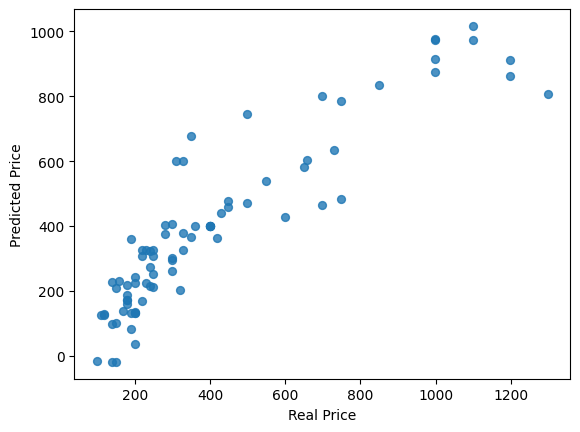

In [ ]:
results.plot(kind='scatter', x='Real Price', y='Predicted Price', s=32, alpha=.8)

In [ ]:
import pickle
with open("model.pkl", "wb") as file:
  pickle.dump(models[1], file)